In [1]:
import sys
sys.path.append("../../BayesFlow")
sys.path.append("../")

import os
if "KERAS_BACKEND" not in os.environ:
    # set this to "torch", "tensorflow", or "jax"
    os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import pickle

import keras

import bayesflow as bf

from dmc import DMC, dmc_helpers

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.lines import Line2D


network_name = 'updated_priors_sdr_estimated'


num_resims = 100
host = 'local'

parent_dir = os.path.dirname(os.getcwd())

model_specs_path = parent_dir + '/model_specs/model_specs_' + network_name + '.pickle'
with open(model_specs_path, 'rb') as file:
    model_specs = pickle.load(file)


simulators  = DMC(**model_specs['simulation_settings'])

approximator  = keras.saving.load_model(parent_dir + "/training_checkpoints/" + network_name + '.keras')



INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).
/home/administrator/miniforge3/envs/bf_new/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 159 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Load PPC data

Before running this script, please make sure to compute empirical estimates (scripts/empirical_estimates.py) and posterior predictive resimulations (scripts/posterior_predictive_check_data.py)

In [19]:
ppc_data_raw = pd.read_csv(parent_dir+'/data_complete/ppc_data/ppc_data_raw.csv')
ppc_data_raw['congruency'] = ppc_data_raw['conditions'].map({0: 'congruent', 1:'incongruent'})


In [20]:
narrow_data = pd.read_csv(parent_dir + '/empirical_data/experiment_data_narrow.csv')
wide_data = pd.read_csv(parent_dir + '/empirical_data/experiment_data_wide.csv')

In [21]:
narrow_data['congruency'] = narrow_data['congruency_num'].map({0: 'congruent', 1:'incongruent'})
wide_data['congruency'] = wide_data['congruency_num'].map({0: 'congruent', 1:'incongruent'})

In [22]:
narrow_data = narrow_data[['participant', 'rt','accuracy', 'congruency']]
wide_data = wide_data[['participant', 'rt','accuracy', 'congruency']]

In [23]:
ppc_data_raw

,Unnamed: 0,rt,accuracy,conditions,num_obs,num_resim,participant,condition_label,model,spacing,congruency
0,0,0.571504,1.0,0,350,0,1108,congruent,updated_priors_sdr_fixed,narrow,congruent
1,1,0.308504,1.0,0,350,0,1108,congruent,updated_priors_sdr_fixed,narrow,congruent
2,2,0.579504,1.0,0,350,0,1108,congruent,updated_priors_sdr_fixed,narrow,congruent
3,3,0.382504,1.0,0,350,0,1108,congruent,updated_priors_sdr_fixed,narrow,congruent
4,4,0.503504,1.0,0,350,0,1108,congruent,updated_priors_sdr_fixed,narrow,congruent
...,...,...,...,...,...,...,...,...,...,...,...
9947073,345,0.390420,1.0,1,350,49,985,incongruent,initial_priors_sdr_estimated,wide,incongruent
9947074,346,0.309370,1.0,1,350,49,985,incongruent,initial_priors_sdr_estimated,wide,incongruent
9947075,347,0.415626,1.0,1,350,49,985,incongruent,initial_priors_sdr_estimated,wide,incongruent
9947076,348,0.376416,1.0,1,350,49,985,incongruent,initial_priors_sdr_estimated,wide,incongruent


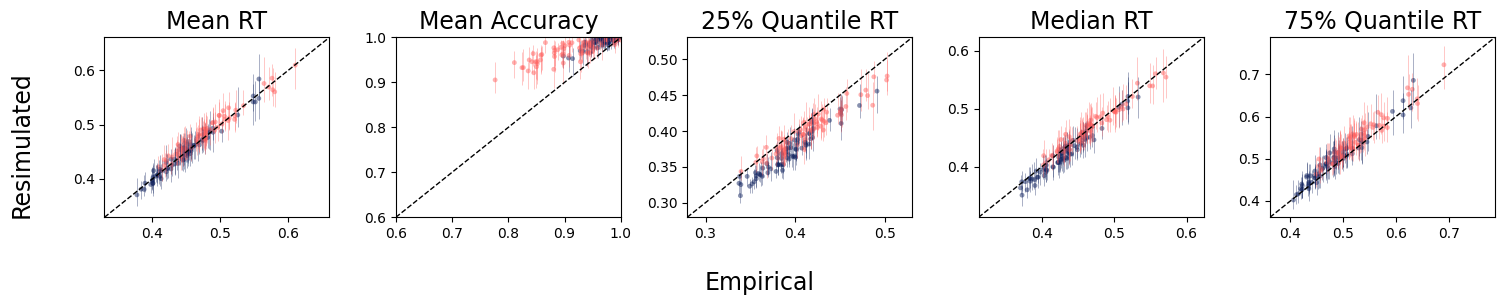

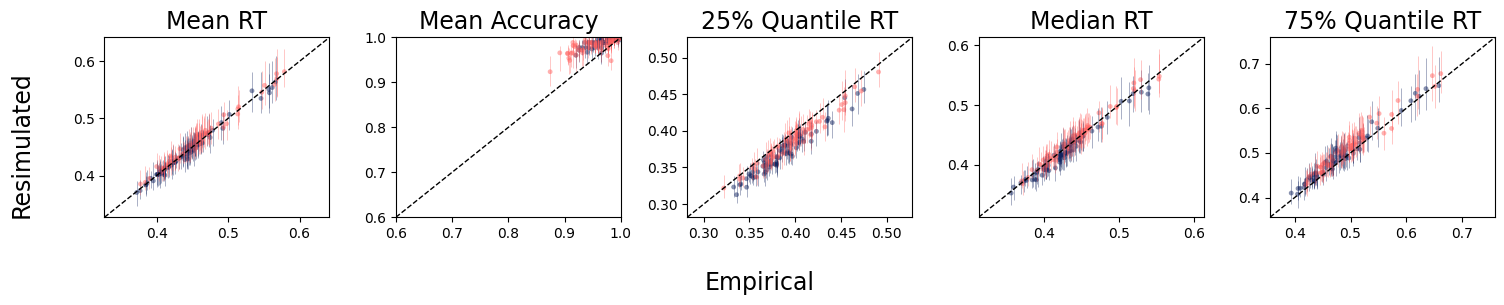

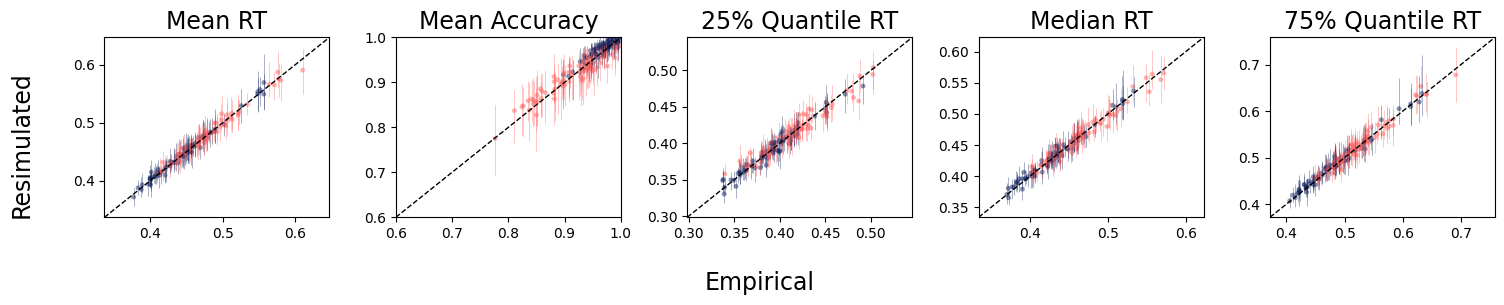

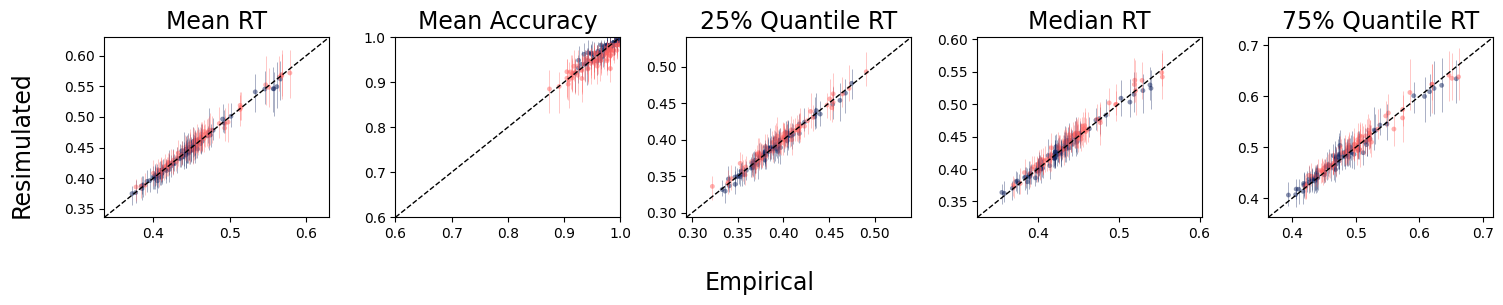

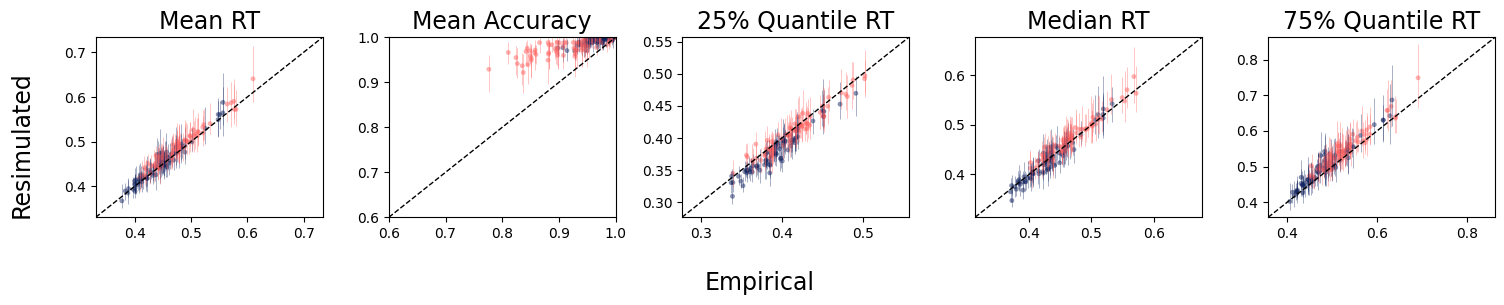

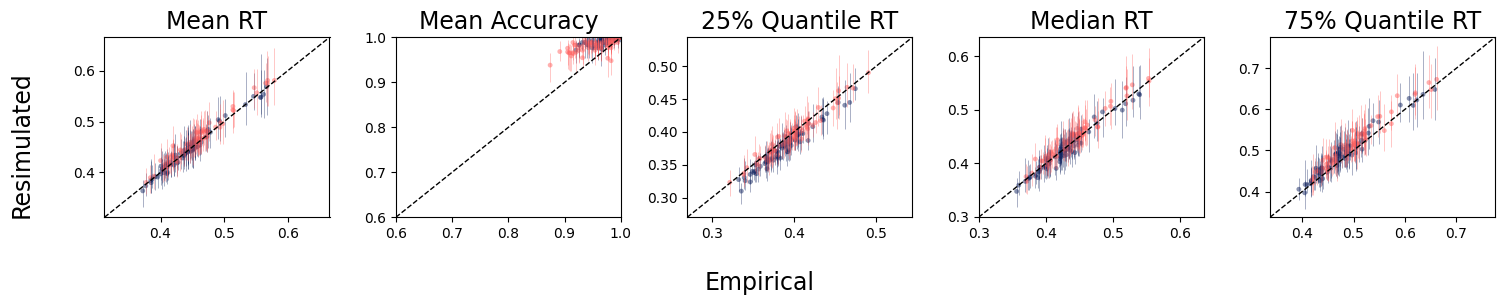

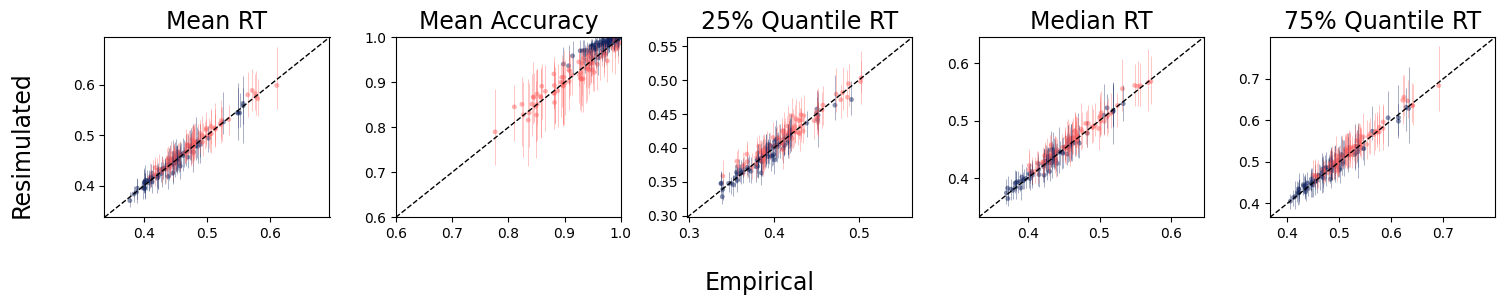

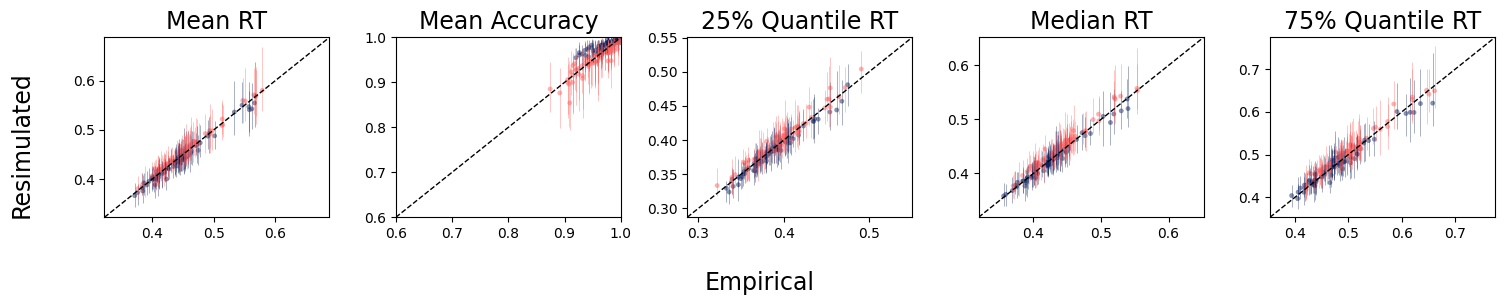

In [24]:

network_names = [
    'updated_priors_sdr_fixed',
    'updated_priors_sdr_estimated',
    'initial_priors_sdr_fixed',
    'initial_priors_sdr_estimated',
]


for model in network_names:

    for spacing in ['narrow', 'wide']:

        if spacing == 'narrow':
            data_fit = narrow_data
        elif spacing == 'wide':
            data_fit = wide_data

        ppc_data = ppc_data_raw[(ppc_data_raw['spacing'] == spacing) & (ppc_data_raw['model'] == model)].copy()

        df_plot = dmc_helpers.compute_fit_qs(resimulated_data=ppc_data, empirical_data=data_fit, id_name='participant', grouping_vars={'participant', 'congruency'}, draw_name='num_resim',summarise_draws=True)

        dmc_helpers.plot_fit_qs(df_plot, plot_uncertainty=True)